# 맨홀-노드 GNN 그래프 구성 (관악구)

**노드 = 맨홀, 엣지 = 상류→하류 유향 관거**(관저고 기반). GIS(sb001 관거·sb101 맨홀)에서 그래프 구조를 만들고
센서(수위계)를 노드에 snap, 노드/엣지 산출물 저장.


In [11]:
import os; os.chdir('/home/namjun/city_flood')
import sys; sys.path.insert(0,'scripts'); from krfont import set_korean; set_korean()
import geopandas as gpd, pandas as pd, numpy as np, networkx as nx, warnings
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
warnings.filterwarnings('ignore')
base="03_GIS/관악구_하수관로_맨홀_shp/"; EB="dataset/processed/eda_based/"
pipe=gpd.read_file(base+"sb001.shp")
p=pipe[pipe.sat_mhe.notna()&pipe.end_mhe.notna()&(pipe.sat_mhe.astype(str).str.strip()!='')&(pipe.end_mhe.astype(str).str.strip()!='')].copy()
p['sat']=p.sat_mhe.astype(str); p['end']=p.end_mhe.astype(str)
print("엣지화 가능 관거",len(p))


엣지화 가능 관거 16059


## 1. 노드(맨홀) — 좌표는 관거 끝점, 지반고/소배수구역 부착

In [12]:
# 노드 좌표 = 관거 geometry 끝점
coords={}
for _,r in p.iterrows():
    c=list(r.geometry.coords); coords.setdefault(r.sat,c[0]); coords.setdefault(r.end,c[-1])
nodes=pd.DataFrame([(k,v[0],v[1]) for k,v in coords.items()],columns=['node_id','x','y'])
# 지반고(hsl): sb101 맨홀에서 mhe_idn 매칭
mh=gpd.read_file(base+"sb101.shp")[['mhe_idn','hsl']].dropna(subset=['mhe_idn'])
mh['mhe_idn']=mh.mhe_idn.astype(str)
nodes=nodes.merge(mh.drop_duplicates('mhe_idn'),left_on='node_id',right_on='mhe_idn',how='left').drop(columns=['mhe_idn'])
# 소배수구역(swa_nam, cp949): 관거에서 노드로
def dec(x):
    try: return x.encode('latin1').decode('cp949')
    except: return x
p['swa']=p.swa_nam.map(dec)
swa=pd.concat([p[['end','swa']].rename(columns={'end':'node_id'}),p[['sat','swa']].rename(columns={'sat':'node_id'})]).dropna().drop_duplicates('node_id')
nodes=nodes.merge(swa,on='node_id',how='left')
print(f"노드 {len(nodes)} | 지반고 보유 {nodes.hsl.notna().mean():.0%} | 소배수구역 보유 {nodes.swa.notna().mean():.0%}")

노드 13272 | 지반고 보유 73% | 소배수구역 보유 100%


## 2. 엣지(유향 관거) — 시점→종점, 길이·경사


In [13]:
p['len']=pd.to_numeric(p.lenx,errors='coerce'); p['si']=pd.to_numeric(p.st_pip_hit,errors='coerce'); p['ei']=pd.to_numeric(p.et_pip_hit,errors='coerce')
edges=p[['sat','end','len','si','ei']].rename(columns={'sat':'src','end':'dst'}).copy()
edges['length']=edges['len'].where(edges['len']>0)
edges['slope']=np.where((edges['len']>0)&(edges.si>0)&(edges.ei>0),(edges.si-edges.ei)/edges['len'],np.nan)
edges=edges[['src','dst','length','slope']]
G=nx.from_pandas_edgelist(edges,'src','dst',edge_attr=['length','slope'],create_using=nx.DiGraph)
print(f"그래프: 노드 {G.number_of_nodes()} 엣지 {G.number_of_edges()} | DAG {nx.is_directed_acyclic_graph(G)} | 약연결성분 {nx.number_weakly_connected_components(G)}")
print(f"  중력방향(시점관저고>종점관저고) 비율 {(edges.slope>0).mean():.0%} | 출구(토구) {sum(1 for _,d in G.out_degree() if d==0)}")


그래프: 노드 13272 엣지 15217 | DAG False | 약연결성분 96
  중력방향(시점관저고>종점관저고) 비율 91% | 출구(토구) 240


## 3. 센서(수위계) → 맨홀 노드 snap (데이터 보유/신설 구분)

In [14]:
gs=gpd.read_file("03_GIS/하수관로_노면_수위계_shp/도시침수계(관로)_서울시 2026.shp")
gs['자치구']=gs['자치구'].astype(str); gs=gs[gs.자치구.str.contains('관악')].to_crs(5181)
have=set(pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id']).sensor_id)
tree=cKDTree(nodes[['x','y']].values)
sx=np.array([(g.x,g.y) for g in gs.geometry]); d,idx=tree.query(sx)
gs2=pd.DataFrame({'sensor_id':gs['수위계번호'].astype(str).values,'node_id':nodes.node_id.values[idx],'snap_m':d})
gs2['is_observed']=gs2.sensor_id.isin(have)
print(f"센서 {len(gs2)} snap(중앙 {np.median(d):.0f}m) | 데이터 보유 {gs2.is_observed.sum()} / 신설 {(~gs2.is_observed).sum()}")
nodes=nodes.merge(gs2[['node_id','sensor_id','is_observed']],on='node_id',how='left')
nodes['is_sensor']=nodes.sensor_id.notna()
# 저장
nodes.to_parquet(EB+"gnn_manhole_nodes.parquet",index=False)
edges.to_parquet(EB+"gnn_manhole_edges.parquet",index=False)
print("저장: gnn_manhole_nodes / gnn_manhole_edges")


센서 42 snap(중앙 9m) | 데이터 보유 13 / 신설 29
저장: gnn_manhole_nodes / gnn_manhole_edges


## 4. 시각화 — 관망 그래프 + 센서 노드

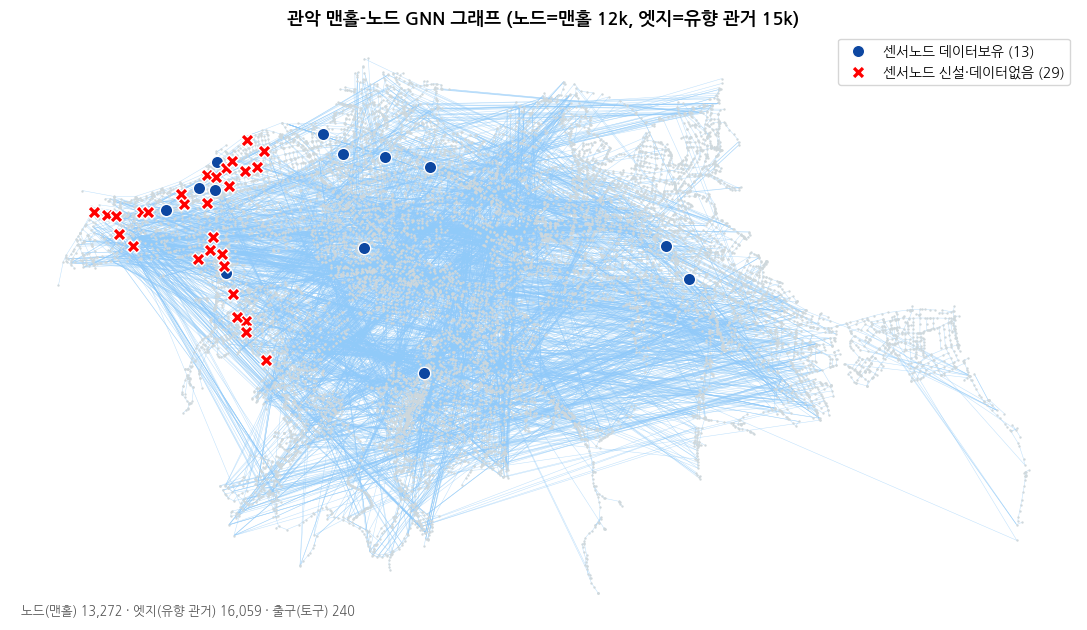

saved


In [15]:
fig,ax=plt.subplots(figsize=(11,9.5))
# 엣지(관거) 선
seg=[]
nd=nodes.set_index('node_id')[['x','y']]
for _,e in edges.iterrows():
    if e.src in nd.index and e.dst in nd.index:
        seg.append([(nd.loc[e.src,'x'],nd.loc[e.src,'y']),(nd.loc[e.dst,'x'],nd.loc[e.dst,'y'])])
from matplotlib.collections import LineCollection
ax.add_collection(LineCollection(seg,colors='#90caf9',linewidths=0.35,alpha=0.6,zorder=1))
ax.scatter(nodes.x,nodes.y,s=0.5,c='#cfd8dc',zorder=2)            # 맨홀
obs=nodes[(nodes.is_sensor==True)&(nodes.is_observed==True)]; new=nodes[(nodes.is_sensor==True)&(nodes.is_observed!=True)]
ax.scatter(obs.x,obs.y,s=80,c='#0d47a1',edgecolor='white',marker='o',zorder=5,label=f'센서노드 데이터보유 ({len(obs)})')
ax.scatter(new.x,new.y,s=90,c='red',edgecolor='white',marker='X',linewidths=1,zorder=5,label=f'센서노드 신설·데이터없음 ({len(new)})')
ax.set_title('관악 맨홀-노드 GNN 그래프 (노드=맨홀 12k, 엣지=유향 관거 15k)',fontsize=13,weight='bold')
ax.set_aspect('equal'); ax.set_axis_off(); ax.legend(fontsize=10,loc='upper right')
ax.text(0.01,0.01,f'노드(맨홀) {len(nodes):,} · 엣지(유향 관거) {len(edges):,} · 출구(토구) {sum(1 for _,dd in G.out_degree() if dd==0)}',transform=ax.transAxes,fontsize=9,color='#555')
plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
plt.savefig('reports/figures_gnn/10_manhole_graph.png',dpi=120,bbox_inches='tight'); plt.show(); print('saved')


## 결론
- **맨홀-노드 유향 그래프 구성 완료**: 노드=맨홀(좌표·지반고·소배수구역), 엣지=상류→하류 관거(길이·경사).
- 센서 42개를 노드에 snap(데이터보유 13·신설 29). → 관측 노드만 라벨(semi-supervised).
- 다음: 노드 입력(맨홀별 강우 유입=강우×집수면적) 구성 — DEM·레이더 필요. 그 전엔 강우 균일가정으로 파이프라인 가동 가능.
